# Association Structure Evaluation — EV Charging Synthetic Data
**Location Group 3 · Real vs each synthetic model configuration**

Evaluates how well each synthetic model reproduces the **dependency structure** among the three key charging variables:

| Variable | Role |
|---|---|
| `plugin_hour` | Time-of-day demand pattern |
| `connection_time` | Session duration (drives overlap) |
| `energy_session` | Delivered energy (drives average power $P = E/t$) |

Two complementary analyses:
1. **Frobenius norm** of the Spearman association-matrix difference — a single scalar per model summarising global dependency fidelity across all variable pairs.
2. **Pairwise 2-D distributions** (hexbin) for the best model per method — visual inspection of joint densities for the three pairs that govern charging overlap and aggregate demand.

Best models from distributional evaluation:
- **CTGAN**: `d2_h8`  (from `evaluation_CTGAN.ipynb`)
- **Diffusion**: `d3_h2`  (from `best_diffusion_cfg.json` — depth=3, nhead=2)

In [6]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import re
import warnings
import os

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
})

# Resolve project root relative to this notebook's location
BASE_DIR = Path(__file__).parent if "__file__" in dir() else Path(os.path.abspath(""))
# If BASE_DIR doesn't contain the data folder, walk up one level
if not (BASE_DIR / "data").exists():
    BASE_DIR = BASE_DIR.parent

LOCATION_GROUP = 3

BEST_CTGAN     = "d2_h8"   # evaluation_CTGAN.ipynb   → synthetic_year_3_d2_8h
BEST_DIFFUSION = "d3_h2"   # best_diffusion_cfg.json  → depth=3, nhead=2

C_REAL  = "#2166ac"
C_CTGAN = "#d6604d"
C_DIFF  = "#4dac26"

ASSOC_COLS = ["plugin_hour", "plugout_hour", "connection_time", "energy_session"]

print(f"BASE_DIR = {BASE_DIR}")
print(f"data dir exists: {(BASE_DIR / 'data').exists()}")


BASE_DIR = /Users/iroshanij/Library/CloudStorage/OneDrive-SINTEF/Iroshani/2025/SynDaGen/synthetic-ev-charging
data dir exists: True


## 1 · Load Data

In [7]:
def filter_sessions(df):
    ok = (
        (df["connection_time"] > 0) & (df["connection_time"] <= 120) &
        (df["energy_session"]  > 0) & (df["energy_session"]  <= 150)
    )
    return df[ok].copy()


def ensure_plugout_hour(df):
    """Add plugout_hour if missing: floor(plugin_hour + connection_time) mod 24."""
    if "plugout_hour" not in df.columns:
        df = df.copy()
        df["plugout_hour"] = np.floor(df["plugin_hour"] + df["connection_time"]).astype(int) % 24
    return df


def safe_read_csv(path):
    """Use Python open() to trigger OneDrive APFS file provider, then parse."""
    with open(str(path), "r", encoding="utf-8") as fh:
        content = fh.read()
    if not content.strip():
        raise pd.errors.EmptyDataError(f"Empty file: {path}")
    return pd.read_csv(io.StringIO(content))


def parse_ctgan_id(stem):
    m = re.search(r"_(d\d)_(\d+)h$", stem)
    if m:
        return f"{m.group(1)}_h{m.group(2)}"
    m = re.search(r"_(d\d)_off$", stem)
    if m:
        return f"{m.group(1)}_h0"
    return None


def parse_diff_id(stem):
    m = re.search(r"_(d\d)_h(\d+)$", stem)
    if m:
        return f"{m.group(1)}_h{m.group(2)}"
    m = re.search(r"_(d\d)_hnone$", stem)
    if m:
        return f"{m.group(1)}_h0"
    return None


# ── Real data ──────────────────────────────────────────────────────────────────
real_raw = safe_read_csv(BASE_DIR / "data" / "EV_Charging_Data_processed.csv")
real_raw = real_raw[real_raw["location_group"] == LOCATION_GROUP].copy()
real_raw = filter_sessions(real_raw)
real_raw = ensure_plugout_hour(real_raw)
real_raw["plugin_time"] = pd.to_datetime(real_raw["plugin_time"])
real_raw["date"]        = real_raw["plugin_time"].dt.date
print(f"Real      : {len(real_raw):>5,} sessions · {real_raw['date'].nunique()} days")

# ── CTGAN ──────────────────────────────────────────────────────────────────────
ctgan_models = {}
for f in sorted((BASE_DIR / "CTGAN" / "synthetic").glob("*.csv")):
    mid = parse_ctgan_id(f.stem)
    if mid is None:
        continue
    try:
        df = filter_sessions(safe_read_csv(f))
    except (pd.errors.EmptyDataError, OSError) as e:
        print(f"  skipped ({type(e).__name__}): {f.name}")
        continue
    df = ensure_plugout_hour(df)
    df["date"] = pd.to_datetime(df["__date__"]).dt.date
    ctgan_models[mid] = df
print(f"CTGAN     : {len(ctgan_models)} models — {sorted(ctgan_models)}")

# ── Diffusion ──────────────────────────────────────────────────────────────────
diff_models = {}
for f in sorted((BASE_DIR / "diffusion" / "synthetic").glob("*.csv")):
    mid = parse_diff_id(f.stem)
    if mid is None:
        continue
    try:
        df = filter_sessions(safe_read_csv(f))
    except (pd.errors.EmptyDataError, OSError) as e:
        print(f"  skipped ({type(e).__name__}): {f.name}")
        continue
    df = ensure_plugout_hour(df)
    df["date"] = pd.to_datetime(df["__date__"]).dt.date
    diff_models[mid] = df
print(f"Diffusion : {len(diff_models)} models — {sorted(diff_models)}")


Real      : 4,665 sessions · 500 days
  skipped (EmptyDataError): synthetic_year_3_d2_2h.csv
  skipped (EmptyDataError): synthetic_year_3_d2_8h.csv
  skipped (EmptyDataError): synthetic_year_3_d3_2h.csv
  skipped (TimeoutError): synthetic_year_3_d3_off.csv
CTGAN     : 12 models — ['d1_h0', 'd1_h2', 'd1_h4', 'd1_h8', 'd2_h0', 'd2_h4', 'd3_h4', 'd3_h8', 'd4_h0', 'd4_h2', 'd4_h4', 'd4_h8']
Diffusion : 16 models — ['d1_h0', 'd1_h2', 'd1_h4', 'd1_h8', 'd2_h0', 'd2_h2', 'd2_h4', 'd2_h8', 'd3_h0', 'd3_h2', 'd3_h4', 'd3_h8', 'd4_h0', 'd4_h2', 'd4_h4', 'd4_h8']


## 2 · Association Matrix Helpers

The **Spearman rank-correlation matrix** is used (rather than Pearson) because `plugin_hour` is ordinal/circular and the other variables are right-skewed.  
The **Frobenius norm** of the element-wise difference $\|C^{real} - C^{syn}\|_F = \sqrt{\sum_{i,j}(c^{real}_{ij} - c^{syn}_{ij})^2}$ aggregates all pairwise discrepancies into one scalar. Lower = better.

In [8]:
def assoc_matrix(df):
    """Spearman rank-correlation matrix for the three key charging variables."""
    sub = df[ASSOC_COLS].dropna().astype(float)
    res = stats.spearmanr(sub)
    # scipy >= 1.7 uses .statistic; older uses .correlation
    corr = getattr(res, "statistic", None)
    if corr is None:
        corr = res.correlation
    return np.atleast_2d(np.array(corr, dtype=float))


def frob_norm(a, b):
    """Frobenius norm of the element-wise difference between two matrices."""
    return float(np.linalg.norm(a - b, "fro"))


# ── Real association matrix ───────────────────────────────────────────────────
mat_real = assoc_matrix(real_raw)
print("Real — Spearman association matrix:")
print(pd.DataFrame(mat_real, index=ASSOC_COLS, columns=ASSOC_COLS).round(3).to_string())

Real — Spearman association matrix:
                 plugin_hour  connection_time  energy_session
plugin_hour            1.000            0.201           0.132
connection_time        0.201            1.000          -0.019
energy_session         0.132           -0.019           1.000


## 3 · Frobenius Norm — Depth × Heads Heatmaps

Each cell shows the Frobenius norm for one (depth, heads) configuration.  
Red = larger deviation from real dependency structure; green = closer.  
Black box = best model identified from distributional evaluation.

── CTGAN (sorted by Frobenius norm ↑ = worse) ──
          depth  heads  frobenius
model_id                         
d2_h2         2      2   0.280253
d3_h4         3      4   0.286402
d4_h4         4      4   0.293109
d1_h0         1      0   0.329251
d3_h8         3      8   0.334892
d4_h2         4      2   0.343190
d4_h0         4      0   0.344682
d1_h4         1      4   0.363537
d2_h8         2      8   0.371508
d2_h4         2      4   0.382264
d3_h0         3      0   0.389171
d2_h0         2      0   0.416971
d4_h8         4      8   0.464086

── Diffusion (sorted by Frobenius norm ↑ = worse) ──
          depth  heads  frobenius
model_id                         
d3_h8         3      8   0.131607
d3_h2         3      2   0.146167
d4_h2         4      2   0.149482
d3_h4         3      4   0.201334
d1_h2         1      2   0.218555
d2_h2         2      2   0.219590
d1_h4         1      4   0.222922
d1_h8         1      8   0.234061
d4_h4         4      4   0.261248
d2_h0        

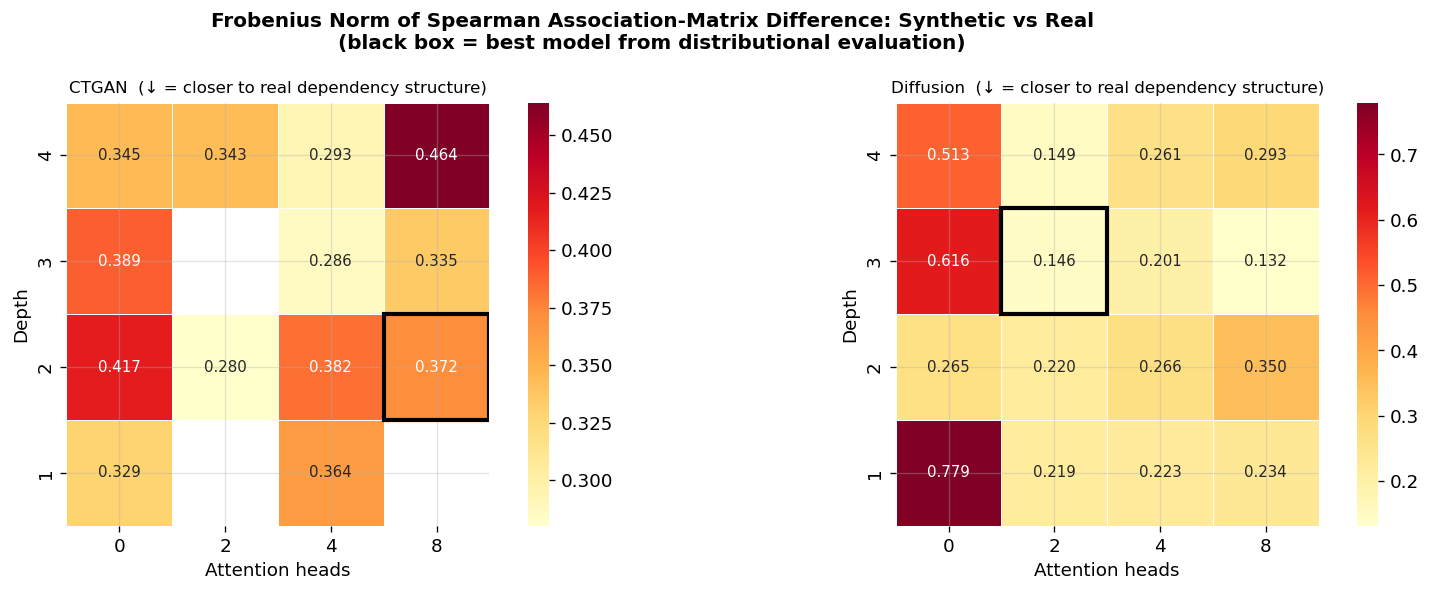

In [9]:
def frob_metrics_df(models_dict):
    rows = []
    for mid, df in models_dict.items():
        m = re.match(r"d(\d+)_h(\d+)", mid)
        rows.append({
            "model_id":  mid,
            "depth":     int(m.group(1)),
            "heads":     int(m.group(2)),
            "frobenius": frob_norm(mat_real, assoc_matrix(df)),
        })
    return pd.DataFrame(rows).set_index("model_id")


ctgan_frob = frob_metrics_df(ctgan_models)
diff_frob  = frob_metrics_df(diff_models)

# Print ranked tables
print("── CTGAN (sorted by Frobenius norm ↑ = worse) ──")
print(ctgan_frob.sort_values("frobenius").to_string())
print("\n── Diffusion (sorted by Frobenius norm ↑ = worse) ──")
print(diff_frob.sort_values("frobenius").to_string())

# ── Heatmaps ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, mdf, best_mid) in zip(axes, [
        ("CTGAN",     ctgan_frob, BEST_CTGAN),
        ("Diffusion", diff_frob,  BEST_DIFFUSION)]):

    piv = (mdf.reset_index()[["depth", "heads", "frobenius"]]
           .pivot_table(index="depth", columns="heads", values="frobenius")
           .sort_index(ascending=False))

    sns.heatmap(piv, annot=True, fmt=".3f", cmap="YlOrRd",
                cbar=True, square=True, linewidths=0.6, linecolor="white",
                annot_kws={"size": 9}, ax=ax)

    bm = re.match(r"d(\d+)_h(\d+)", best_mid)
    if bm:
        bd, bh = int(bm.group(1)), int(bm.group(2))
        if bd in piv.index.tolist() and bh in piv.columns.tolist():
            ri = list(piv.index).index(bd)
            ci = list(piv.columns).index(bh)
            ax.add_patch(plt.Rectangle((ci, ri), 1, 1, fill=False,
                                       edgecolor="black", lw=2.5, zorder=5))

    ax.set_title(f"{label}  (↓ = closer to real dependency structure)", fontsize=10)
    ax.set_xlabel("Attention heads")
    ax.set_ylabel("Depth")

plt.suptitle(
    "Frobenius Norm of Spearman Association-Matrix Difference: Synthetic vs Real\n"
    "(black box = best model from distributional evaluation)",
    fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("assoc_frobenius_heatmap.png", bbox_inches="tight")
plt.show()

## 4 · Side-by-Side Association Matrices — Best Models

Direct comparison of the Spearman correlation matrices for the real dataset and the best synthetic model from each method.  
Values range from −1 (strong negative) to +1 (strong positive); colour scale is centred at zero.

Frobenius norm (lower = closer to real dependency structure):
  Real vs CTGAN  d2_h8                  : 0.3715
  Real vs Diffusion  d3_h2              : 0.1462


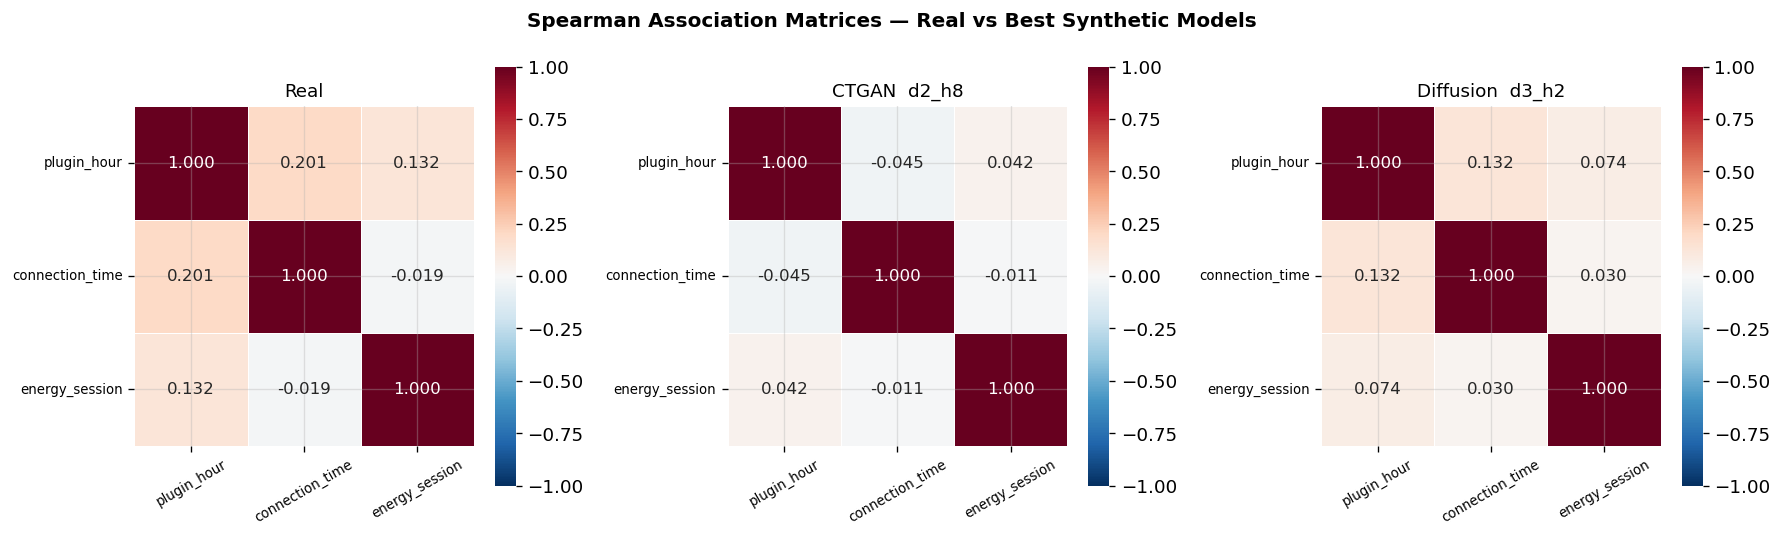

In [10]:
datasets_assoc = [
    ("Real",                            real_raw),
    (f"CTGAN  {BEST_CTGAN}",            ctgan_models[BEST_CTGAN]),
    (f"Diffusion  {BEST_DIFFUSION}",    diff_models[BEST_DIFFUSION]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
mats = []

for ax, (label, df) in zip(axes, datasets_assoc):
    mat = assoc_matrix(df)
    mats.append(mat)
    sns.heatmap(
        pd.DataFrame(mat, index=ASSOC_COLS, columns=ASSOC_COLS),
        annot=True, fmt=".3f", cmap="RdBu_r",
        center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.6, cbar=True, ax=ax,
        annot_kws={"size": 10},
    )
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

print("Frobenius norm (lower = closer to real dependency structure):")
for (label, _), mat in zip(datasets_assoc[1:], mats[1:]):
    print(f"  Real vs {label:30s}: {frob_norm(mats[0], mat):.4f}")

plt.suptitle("Spearman Association Matrices — Real vs Best Synthetic Models",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("assoc_matrices_best.png", bbox_inches="tight")
plt.show()

## 5 · Pairwise 2-D Distributions — Key Charging Variables

Visual inspection of joint distributions for the three variable pairs that govern charging overlap and aggregate demand:

| Pair | Why it matters |
|---|---|
| Plug-in hour × Connection time | Determines how sessions overlap on the timeline |
| Plug-in hour × Energy (kWh) | Captures time-of-day demand intensity |
| Connection time × Energy (kWh) | Governs average charging power $P = E / t_{conn}$ |

Hexbin density (darker = more sessions). Spearman $\rho$ annotated on each panel.

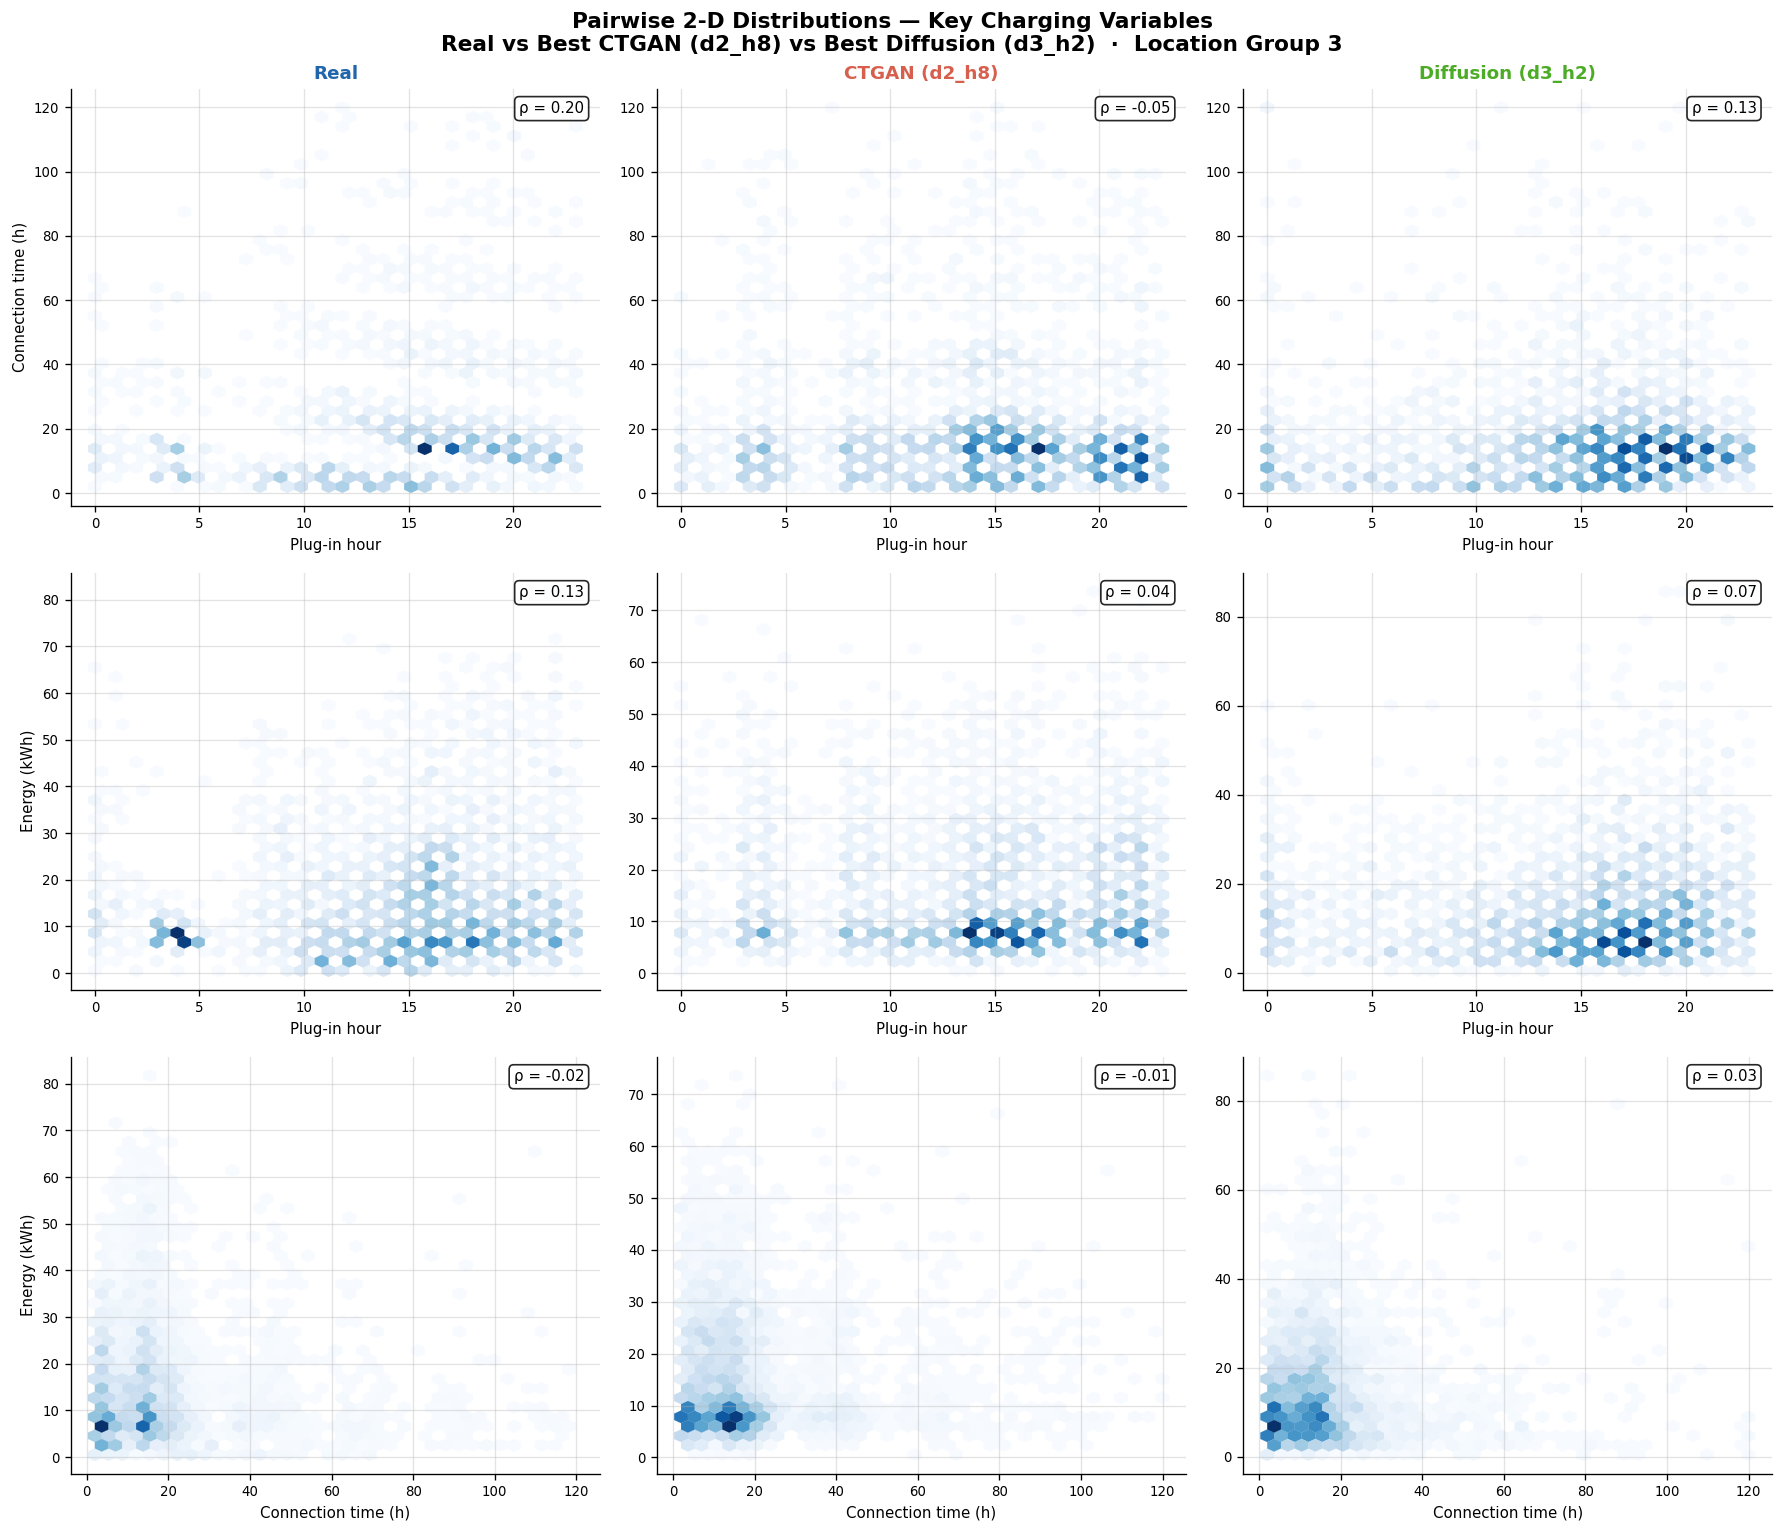

In [ ]:
PAIRS = [
    ("plugin_hour",     "plugout_hour",     "Plug-in hour",        "Plug-out hour"),
    ("plugin_hour",     "connection_time",  "Plug-in hour",        "Connection time (h)"),
    ("plugin_hour",     "energy_session",   "Plug-in hour",        "Energy (kWh)"),
    ("connection_time", "energy_session",   "Connection time (h)", "Energy (kWh)"),
]

datasets_2d = [
    ("Real",                             real_raw,                    C_REAL),
    (f"CTGAN ({BEST_CTGAN})",            ctgan_models[BEST_CTGAN],    C_CTGAN),
    (f"Diffusion ({BEST_DIFFUSION})",    diff_models[BEST_DIFFUSION], C_DIFF),
]

fig, axes = plt.subplots(len(PAIRS), len(datasets_2d), figsize=(15, 17))

for row, (xcol, ycol, xlabel, ylabel) in enumerate(PAIRS):
    for col, (label, df, color) in enumerate(datasets_2d):
        ax = axes[row, col]

        sub = (df[[xcol, ycol]]
               .dropna()
               .astype(float)
               .sample(min(5000, len(df)), random_state=42))

        ax.hexbin(sub[xcol], sub[ycol],
                  gridsize=35, cmap="Blues", mincnt=1, linewidths=0.1)

        rho, _ = stats.spearmanr(sub[xcol], sub[ycol])
        ax.text(0.97, 0.97, f"ρ = {rho:.2f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(ylabel if col == 0 else "", fontsize=9)
        ax.tick_params(labelsize=8)

        if row == 0:
            ax.set_title(label, fontsize=11, fontweight="bold", color=color)

plt.suptitle(
    "Pairwise 2-D Distributions — Key Charging Variables\n"
    f"Real vs Best CTGAN ({BEST_CTGAN}) vs Best Diffusion ({BEST_DIFFUSION})  ·  "
    f"Location Group {LOCATION_GROUP}",
    fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("assoc_pairwise_2d.png", bbox_inches="tight")
plt.show()
